In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from tbparse import SummaryReader

In [7]:


# ==========================================
# ZELLE 1: KONFIGURATION & DATEN LADEN
# ==========================================
# Welchen Hauptordner willst du gerade analysieren? (z.B. logs/key_c)
LOG_DIR = "logs/locked_c"  

# DEINE FESTE FARBE FÜR DIESE METHODE IN DER GANZEN ARBEIT
METHOD_COLOR = "blue" 
"orange"
print(f"Lade alle Runs aus dem Ordner '{LOG_DIR}'...")

# HIER IST DER FIX: Ein Set {'dir_name'} anstelle eines Dictionaries!
reader = SummaryReader(LOG_DIR, extra_columns={'dir_name'})
df_all_runs = reader.scalars

# Zeige zur Kontrolle, welche Unterordner gefunden wurden
runs_found = df_all_runs['dir_name'].unique()
print(f"Fertig! Gefundene Runs: {len(runs_found)}")
for run in runs_found:
    print(f" - {run}")

Lade alle Runs aus dem Ordner 'logs/locked_c'...
Fertig! Gefundene Runs: 5
 - _run_0
 - _run_1
 - _run_2
 - _run_3
 - _run_4


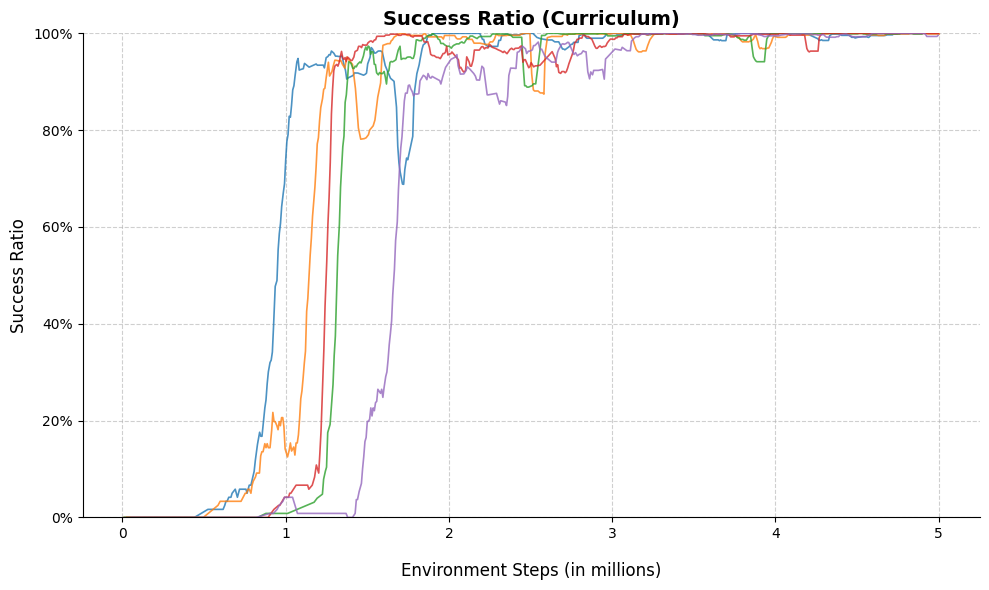

In [8]:
# ==========================================
# ZELLE 2: FILTERN & PLOTTEN (Glättung & Clean Look)
# ==========================================
TARGET_TAG = "Success ratio %/locked_room" 

PLOT_TITLE = "Success Ratio (Curriculum)" 
X_AXIS_LABEL = "Environment Steps (in millions)"
Y_AXIS_LABEL = "Success Ratio" # <-- Neua

# Wie stark soll geglättet werden? (z.B. 10, 20 oder 50)
# Je höher die Zahl, desto weicher die Linie.
SMOOTHING_WINDOW = 10 

# 1. Filtern & Sortieren
df_plot = df_all_runs[df_all_runs['tag'] == TARGET_TAG].copy()
df_plot = df_plot.sort_values(by='step')

# HIER IST DIE MAGIE FÜRS GLÄTTEN:
# Wir berechnen den gleitenden Mittelwert separat für jeden Run (dir_name)
df_plot['smoothed_value'] = df_plot.groupby('dir_name')['value'].transform(
    lambda x: x.rolling(SMOOTHING_WINDOW, min_periods=1).mean()
)

# 2. Plotten
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_plot, 
    x='step', 
    y='smoothed_value', # <-- Wir plotten jetzt die geglätteten Werte!
    hue='dir_name',
    linewidth=1.2,      # Minimal dicker, weil es jetzt weniger rauscht
    alpha=0.8,          
    legend=False        
)

# 3. Beschriftungen und Formatierung
plt.title(PLOT_TITLE, fontsize=14, fontweight='bold')
plt.xlabel(X_AXIS_LABEL, fontsize=12, labelpad=15) 
plt.ylabel(Y_AXIS_LABEL, fontsize=12) # <-- Beschriftung repariert

plt.ylim(0, 1.0)
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1e6:g}'))
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.grid(True, linestyle='--', alpha=0.6)

# HIER IST DER CLEAN LOOK:
sns.despine() # Entfernt die Linien oben und rechts

plt.tight_layout()
plt.show()

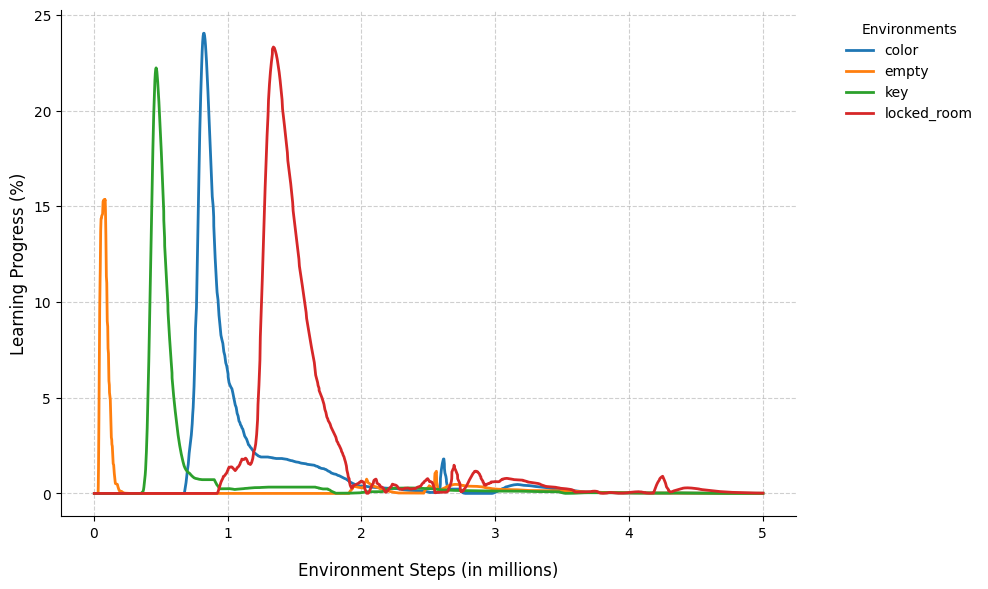

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ==========================================
# ZELLE 2: MULTI-METRIK PLOT FÜR EINEN RUN
# ==========================================
# 1. Konfiguration
REPRESENTATIVE_RUN = "_run_0" 


METRIC_KEYWORD = "Teacher_LP"
"Success ratio %"
"Teacher_LP"
"# Selected"
Y_AXIS_LABEL = "Learning Progress" # Ändern in "Success Ratio", wenn du Success Ratio plottest
"# selections"
"Learning Progress"
"Success ratio"
# Glättung
SMOOTHING_WINDOW = 10

# NEU: Steuerung der Normalisierung (Mal 100 rechnen)
NORMALIZE = True  # True = Werte * 100 (z.B. für Success Ratios), False = Raw-Werte lassen
Y_MIN = -5
Y_MAX = 105
ENFORCE_BOUNDS = True  # True = limitiert nach oben, False = skaliert oben automatisch

# ==========================================
# DATENVERARBEITUNG
# ==========================================
# A) Nur den ausgewählten Run behalten
df_run = df_all_runs[df_all_runs['dir_name'].str.contains(REPRESENTATIVE_RUN)].copy()

# B) Nur die relevanten Metriken behalten
df_metrics = df_run[df_run['tag'].str.contains(METRIC_KEYWORD)].copy()

# C) Tag-Namen für eine saubere Legende bereinigen
df_metrics['Task'] = df_metrics['tag'].apply(lambda x: x.split('/')[-1] if '/' in x else x)

# D) Glätten
df_metrics['smoothed_value'] = df_metrics.groupby('Task')['value'].transform(
    lambda x: x.rolling(SMOOTHING_WINDOW, min_periods=1).mean()
)
df_metrics = df_metrics.dropna(subset=['smoothed_value'])

# E) Normalisierung anwenden, falls gewünscht
if NORMALIZE:
    df_metrics['smoothed_value'] = df_metrics['smoothed_value'] * 100

# ==========================================
# PLOTTEN
# ==========================================
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_metrics, 
    x='step', 
    y='smoothed_value', 
    hue='Task', 
    linewidth=2
)

# ==========================================
# STYLING
# ==========================================
plt.xlabel("Environment Steps (in millions)", fontsize=12, labelpad=15)

# Label anpassen basierend auf Normalisierung
if NORMALIZE:
    plt.ylabel(f"{Y_AXIS_LABEL} (%)", fontsize=12)
else:
    plt.ylabel(Y_AXIS_LABEL, fontsize=12)

# X-Achse als Millionen formatieren
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1e6:g}'))

# Y-Achse auf fixen Bereich skalieren
if ENFORCE_BOUNDS:
    plt.ylim(bottom=Y_MIN, top=Y_MAX)


sns.despine() 
plt.grid(True, linestyle='--', alpha=0.6)

# Legende außerhalb platzieren (rechts oben)
plt.legend(
    title="Environments", 
    frameon=False, 
    bbox_to_anchor=(1.05, 1), 
    loc='upper left'          
)

plt.tight_layout()
plt.show()